In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from functools import reduce
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import PercentFormatter
from scipy.ndimage import gaussian_filter1d
from scipy.stats import mannwhitneyu
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

plt.rcParams.update({
  "font.size": 9,
  "axes.titlesize": 9,
  "axes.labelsize": 9,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "legend.fontsize": 9
})

## Weight dynamics under varying synaptic input frequencies

In [2]:
carrier = 1000
beat = 5
amplitudes = [ 0.5, 0.9 ]
frequencies = np.arange(1, 26)
cell_ids = np.arange(0, 20)

def expand_time(original, max_time = 10_000, time_step = 0.025):
  original["Time"] = (original["Time"] / time_step).round() * time_step
  original = original.sort_values("Time")

  new_time = np.arange(0, max_time + time_step, time_step)

  expanded = pd.DataFrame({ "Time": new_time })
  expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

  return expanded

stims = [f"{carrier}_{beat}_{amplitude}" for amplitude in amplitudes] + ["noTI"]
weights = {}
for stim in stims:
  print(f"Processing stimulus {stim}")
  weights[ stim ] = {}
  for frequency in frequencies:
    print(f"Processing frequency {frequency} Hz")
    cell_weights = []
    for cell_id in cell_ids:
      filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/synapse_weights.csv"
      
      df = pd.read_csv(filename, index_col = 0)
      df = expand_time(df).set_index("Time")

      # make synapse columns unique per cell
      syn_cols = [c for c in df.columns if c != "Time"]
      df = df.rename(columns={c: f"{c}_cell{cell_id}" for c in syn_cols})

      cell_weights.append(df)

    # merge all on Time
    cell_weights = reduce(lambda left, right: pd.merge(left, right, on="Time", how="inner"), cell_weights)
    weights[ stim ][ frequency ] = cell_weights

Processing stimulus 1000_5_0.5
Processing frequency 1 Hz
Processing frequency 2 Hz
Processing frequency 3 Hz
Processing frequency 4 Hz
Processing frequency 5 Hz
Processing frequency 6 Hz
Processing frequency 7 Hz
Processing frequency 8 Hz
Processing frequency 9 Hz
Processing frequency 10 Hz
Processing frequency 11 Hz
Processing frequency 12 Hz
Processing frequency 13 Hz
Processing frequency 14 Hz
Processing frequency 15 Hz
Processing frequency 16 Hz
Processing frequency 17 Hz
Processing frequency 18 Hz
Processing frequency 19 Hz
Processing frequency 20 Hz
Processing frequency 21 Hz
Processing frequency 22 Hz
Processing frequency 23 Hz
Processing frequency 24 Hz
Processing frequency 25 Hz
Processing stimulus 1000_5_0.9
Processing frequency 1 Hz
Processing frequency 2 Hz
Processing frequency 3 Hz
Processing frequency 4 Hz
Processing frequency 5 Hz
Processing frequency 6 Hz
Processing frequency 7 Hz
Processing frequency 8 Hz
Processing frequency 9 Hz
Processing frequency 10 Hz
Processing 

In [4]:
colors = {
  "No tTIS": "#0D0887",
  "50% tTIS": "#E16462",
  "90% tTIS": "#B12A90"
}

example_frequencies = [ 5, 10, 20 ]
effective_stims = [f"{carrier}_{beat}_{amplitude}" for amplitude in amplitudes]
noneffective_stim = "noTI"

stim_labels = {
  '1000_5_0.5': "50% tTIS", 
  '1000_5_0.9': "90% tTIS",
  'noTI': "No tTIS"
}

In [5]:
def moving_average(y, window):
  kernel = np.ones(window) / window
  return np.convolve(y, kernel, mode="same")


def plot_weight_change(synaptic_weights, label, color, window, ax):
  # Calculate weight change average
  change = synaptic_weights - 0.1
  change = np.abs(change)
  mean_change = change.mean(axis = 1)

  errors = change.std(axis = 1) / np.sqrt(change.shape[1])

  change = pd.DataFrame({
    "Time": synaptic_weights.index / 1000,
    "Change": mean_change,
    "Error": errors
  }).reset_index(drop = True)

  # smooth
  smoothed_change = moving_average(change.Change.values, window)
  smoothed_error = moving_average(change.Error.values, window)
 
  last_index = len(smoothed_change) - int(window / 2) - 1
  smoothed_change[ last_index:len(smoothed_change) ] = smoothed_change[ last_index ]
  smoothed_error[ last_index:len(smoothed_error) ] = smoothed_error[ last_index ]

  ax.plot(
    change.Time,
    smoothed_change,
    linewidth = 0.5,
    label = label,
    color = color
  )

  ax.fill_between(
    change.Time,
    smoothed_change - smoothed_error,
    smoothed_change + smoothed_error,
    alpha = 0.5,
    color = color,
    edgecolor = None
  )

  ax.set_xlabel("Time, s")

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  
  ax.set_ylim(0, 0.45)
  ax.grid(alpha = 0.5)
  ax.autoscale(False)

In [6]:
def plot_pontentiated_fraction(weights, stims, frequencies, ax):
  def categorize_potentiation(w):
    if w == 0.1: return "No change"
    return "Change"

  categories = ["No change", "Change"]

  weight_categories = []
  for stim in stims:
    for frequency in frequencies:
      weight_categories.append(
        pd.DataFrame({
          "Category": weights[stim][frequency].iloc[-1, :].apply(categorize_potentiation),
          "Frequency": frequency,
          "Stimulation": stim
        })
      )

  weight_categories = pd.concat(weight_categories, ignore_index = True)

  # compute fractions for all stimulations
  category_fractions = []

  for stim in stims:
    categories = weight_categories[
      weight_categories.Stimulation == stim
    ]
    
    counts = categories.groupby(["Frequency", "Category"]).size().unstack(fill_value = 0)
    fractions = counts.div(counts.sum(axis = 1), axis = 0).reset_index()
    
    fractions["Stimulation"] = stim
    category_fractions.append(fractions)

  category_fractions = pd.concat(category_fractions, ignore_index = True)

  for stim in stims:
    label = stim_labels[stim]
    stim_fractions = category_fractions[ category_fractions.Stimulation == stim ]
    ax.plot(
      stim_fractions.Frequency,
      stim_fractions.Change * 100,
      color = colors[label],
      label = label
    )

    ax.scatter(
      stim_fractions.Frequency,
      stim_fractions.Change * 100,
      s = 20,
      c = colors[label]
    )
  
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)

  ax.set_xlabel("Frequency, Hz")
  ax.set_ylabel("Plastic synapses, %")
  ax.set_ylim(0, 110)
  ax.grid(alpha = 0.25)

In [61]:
def plot_weight_difference(frequencies, effective_stims, noneffective_stim, weights, ax, colors, stim_labels):
  # Calculate the data for the plot
  gained_weights = []
  for stim in effective_stims:
    for f in frequencies:
      time_points = weights[stim][f].index > 9.5 * 1000
      change_ti = np.abs(weights[stim][f].iloc[time_points, :] - 0.1).median(axis = 0)
      change_noti = np.abs(weights[noneffective_stim][f].iloc[time_points, :] - 0.1).median(axis = 0)
      difference = change_ti - change_noti

      stat, p = wilcoxon(change_noti, change_ti)
      gained_weights.append(
        pd.DataFrame({
          "Frequency": [f],
          "Stim": stim,
          "Mean": np.mean(difference),
          "Error": difference.std() / np.sqrt(difference.shape[0]),
          "P": p
        })
      )

  gained_weights = pd.concat(gained_weights)

  # Plot
  ax.axhline(y = 0, linestyle = "-", linewidth = 0.5, color = "black", zorder = 0)

  for stim in effective_stims:
    dt = gained_weights[gained_weights.Stim == stim]
    sig = dt[dt.P < 0.05]
    nonsig = dt[dt.P >= 0.05]
    label = stim_labels[stim]

    ax.plot(
      dt.Frequency, dt.Mean,
      color = colors[label],
      zorder = 1
    )

    ax.fill_between(
      dt.Frequency,
      dt.Mean - dt.Error,
      dt.Mean + dt.Error,
      alpha = 0.25,
      color = colors[label],
      edgecolor = None
    )

    ax.scatter(
      sig.Frequency,
      sig.Mean,
      color = colors[label],
      label = label,
      s = 25,
      zorder = 3
    )

    ax.scatter(
      nonsig.Frequency,
      nonsig.Mean,
      facecolors = "white",
      edgecolors = colors[label],
      s = 25,
      alpha = 1,
      zorder = 5
    )

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.grid(alpha = 0.25)
  ax.set_ylabel(r"Mean $\Delta$ weight")
  ax.set_xlabel("Frequency, Hz")

  legend_elements = [
    Line2D([0], [0], marker = "o", color = "k", markerfacecolor = "k", markersize = 3, linestyle = "None", label = "Significant"),
    Line2D([0], [0], marker = "o", color = "k", markerfacecolor = "none", markersize = 3, linestyle = "None", label = "Not significant"),
  ]

  ax.legend(
    title = "Significance\n(P < 0.05)",
    handles = legend_elements,
    loc = "center right",
    ncols = 1,
    frameon = False,
    bbox_to_anchor = (1, 0.85),
    handletextpad = 0.25
  )

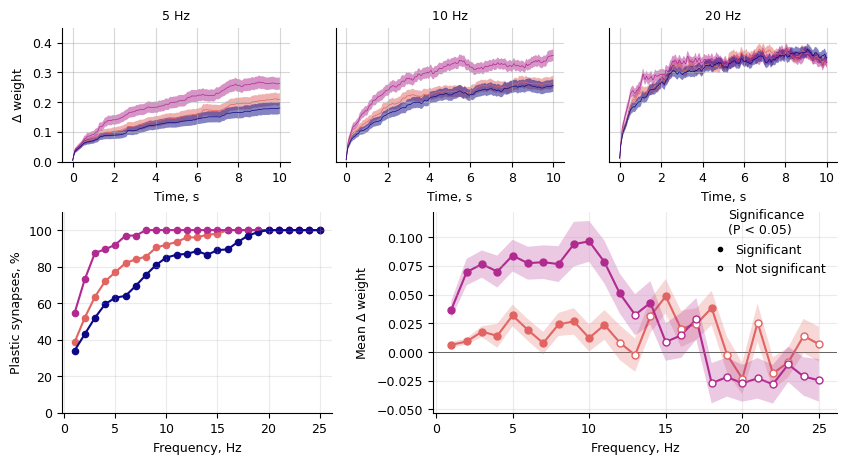

In [66]:
fig = plt.figure(figsize=(10, 5))

outer_gs = gridspec.GridSpec(
  2, 1,
  height_ratios = [0.8, 1.2],
  hspace = 0.3
)

# --- FIRST ROW: 3 panels ---

row_1 = gridspec.GridSpecFromSubplotSpec(
  1, 3,
  subplot_spec = outer_gs[0],
  width_ratios = [1, 1, 1],
  wspace = 0.2
)

ax_row1_col1 = fig.add_subplot(row_1[0])
ax_row1_col2 = fig.add_subplot(row_1[1], sharey = ax_row1_col1)
ax_row1_col3 = fig.add_subplot(row_1[2], sharey = ax_row1_col1)

# --- SECOND ROW: 2 panels ---

row_2 = gridspec.GridSpecFromSubplotSpec(
  1, 2,
  subplot_spec = outer_gs[1],
  width_ratios = [0.8, 1.2],
  wspace = 0.3
)

ax_row2_col1 = fig.add_subplot(row_2[0])
ax_row2_col2 = fig.add_subplot(row_2[1])

# --- FIRST ROW: synaptic weight dynamics during selected example frequencies

for ax, f in zip([ax_row1_col1, ax_row1_col2, ax_row1_col3], example_frequencies):
  for stim in stims:
    label = stim_labels[stim]
    plot_weight_change(
      weights[stim][f],
      label = label,
      color = colors[label],
      window = 2500,
      ax = ax
    )
  
  ax.set_title(f"{f} Hz")

# Adjust the labels
ax_row1_col1.set_ylabel(r"$\Delta$ weight")
for ax in [ax_row1_col2, ax_row1_col3]:
  ax.tick_params(axis = "y", which = "both", left = False, labelleft = False)

# --- SECOND ROW: fraction of potentiated synapses and average weight change

plot_pontentiated_fraction(weights, stims, frequencies, ax_row2_col1)
plot_weight_difference(frequencies, effective_stims, noneffective_stim, weights, ax_row2_col2, colors, stim_labels)

plt.savefig("figure-results_input-frequency.png", dpi = 500, bbox_inches = "tight", transparent = True)

## Additional figure stuff

In [203]:
def read_spike_times(idx, rate, carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    global project
    
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"

    spike_times = pd.read_csv(
        f"../output/temporal-interference-1/{idx}/random_poisson/{rate}/{filename}/synapse_stimuli.csv",
        header = None
    )
    spike_times = spike_times.fillna('').values.tolist()
    spike_times = [[x for x in row if x != ""] for row in spike_times]

    return spike_times

idx = 0
rate = 5
initial_weight = 0.1

spike_times = read_spike_times(
    idx = idx,
    rate = rate,
    initial_weight = initial_weight,
    carrier = None
)

colors = {
    "No tTIS": "#0D0887",
    "90% tTIS": "#B12A90",
    "50% tTIS": "#E16462"
}

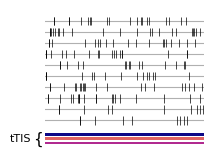

In [227]:
fig = plt.figure(figsize = (8.4, 14))

outer_gs = gridspec.GridSpec(9, 1, height_ratios = [1, 0.2, 2.5, 0.5, 0.7, 0.25, 0.7, 0.25, 0.7])

# --- A and B panels ---

inner_gs_1 = gridspec.GridSpecFromSubplotSpec(
    4, 4,
    subplot_spec=outer_gs[0],
    width_ratios=[0.1, 0.2, 0.11, 0.3],
    height_ratios=[0.9, 0.02, 0.02, 0.02],
    hspace = 0.05
)

### A

ax_a = fig.add_subplot(inner_gs_1[0, 1])

for i, spikes in enumerate(spike_times):
    ax_a.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

ax_a.set_ylim(0, 11)
ax_a.set_yticks(np.arange(1, 11, 1))
ax_a.set_yticklabels([])
ax_a.tick_params(axis = "y", labelleft = False, which = "both", left = False)

ax_a.set_xlabel("")
ax_a.set_xlim(0, 3000)
ax_a.tick_params(axis = "x", labelbottom = False, which = "both", bottom = False)

ax_a.grid(True)
ax_a.xaxis.grid(False)
ax_a.yaxis.grid(True)

sns.despine(ax = ax_a, top = True, bottom = True, left = True, right = True)

ax = fig.add_subplot(inner_gs_1[1, 1])

ax.axvspan(
    0,
    3000,
    color = colors["No tTIS"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax = fig.add_subplot(inner_gs_1[2, 1])

ax.axvspan(
    0,
    3000,
    color = colors["50% tTIS"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# --- new 90% tTIS line (row 3) ---
ax = fig.add_subplot(inner_gs_1[3, 1])

ax.axvspan(
    0,
    3000,
    color = colors["90% tTIS"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left=False, labelleft=False, labelbottom=False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.225, 0.7875, "tTIS", fontsize = 8, va = "center", ha = "center")
fig.text(0.245, 0.7875, "{", fontsize = 11, va = "center", ha = "center")

plt.savefig("figure-results_protocol-frequency.png", dpi = 500, bbox_inches = "tight", transparent = True)